<a href="https://www.kaggle.com/code/nilotpaldhar/end-to-end-ml-pipeline-for-customer-churn-predict?scriptVersionId=304208310" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


<a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Import Libraries</div>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
df=pd.read_csv(r"/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Data Cleaning</div>

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
X=df.drop(['customerID','Churn'],axis=1)
y=df[['Churn']]

<a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Exploratory Data Analysis</div>

In [12]:
county=y.value_counts()
county

Churn
No       5174
Yes      1869
Name: count, dtype: int64

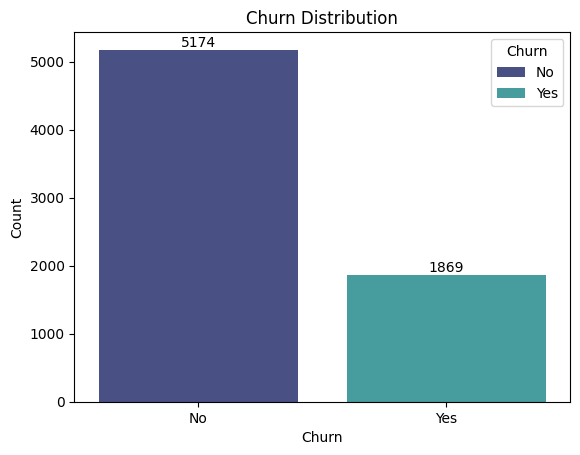

In [13]:
g=sns.countplot(data=df,x='Churn',hue='Churn',palette='mako',legend=True)
for i in g.containers:
    g.bar_label(i)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Churn Distribution')
plt.show()

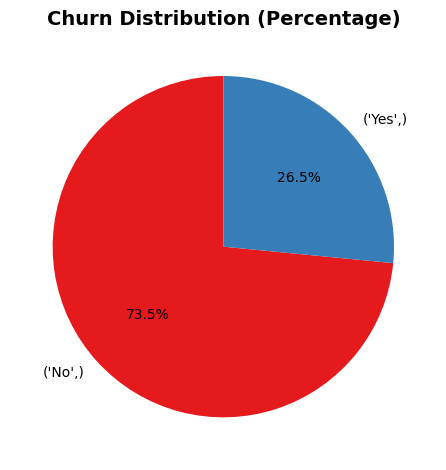

In [14]:
plt.pie(county, labels=county.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('Set1'))
plt.title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

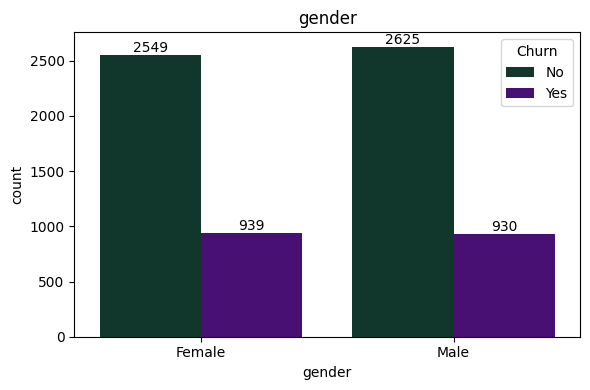

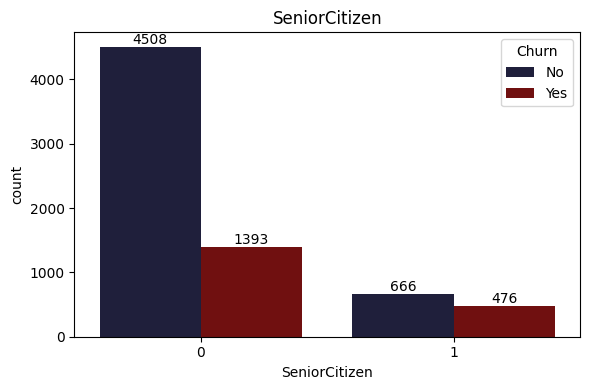

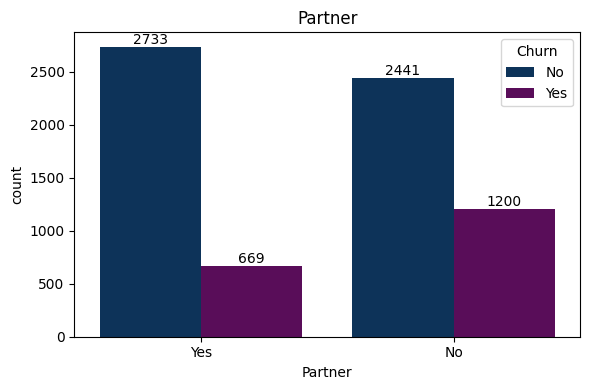

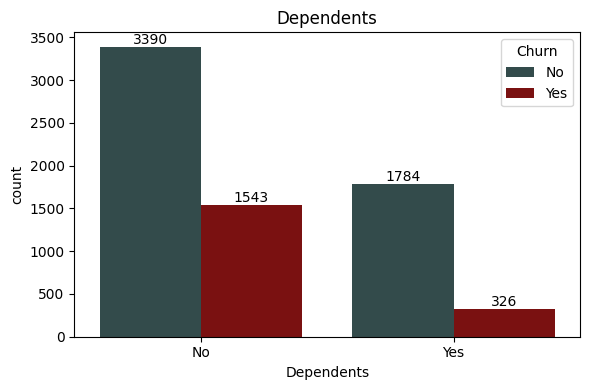

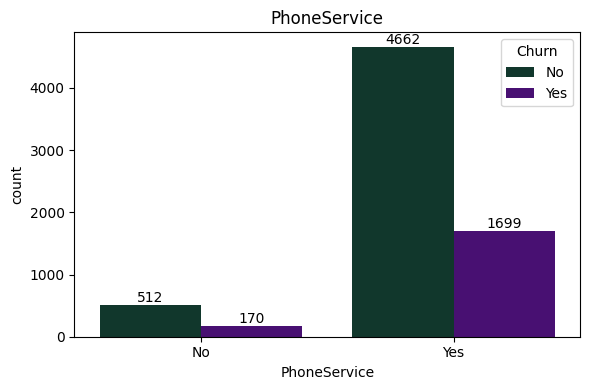

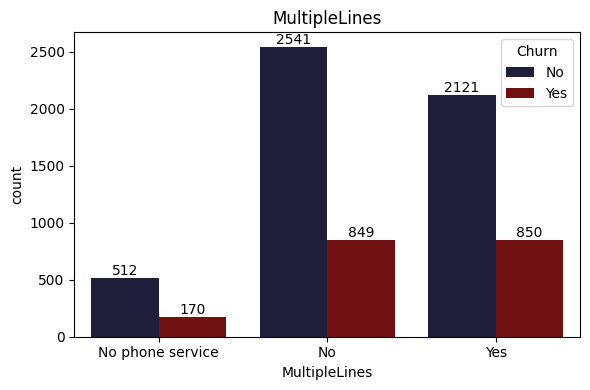

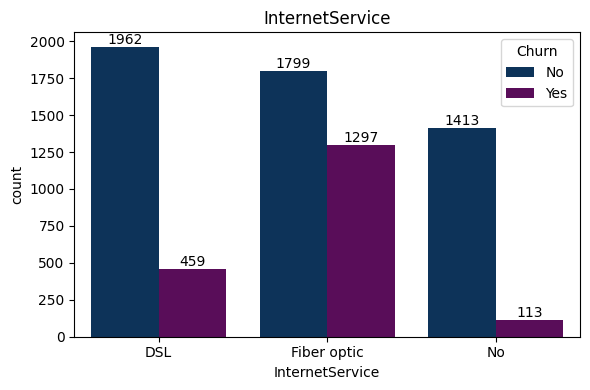

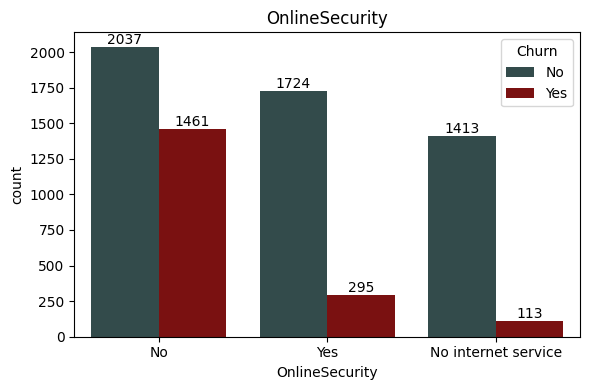

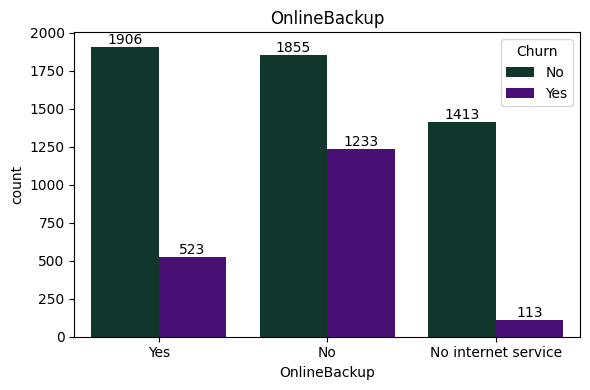

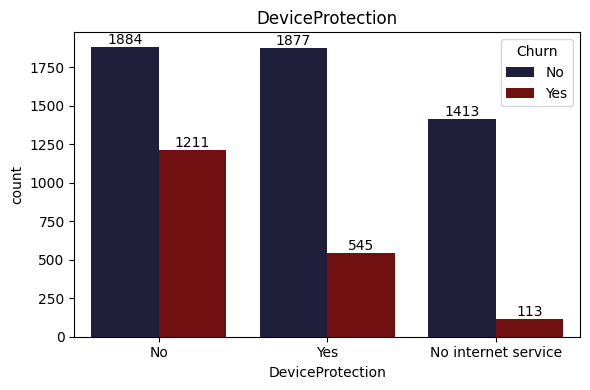

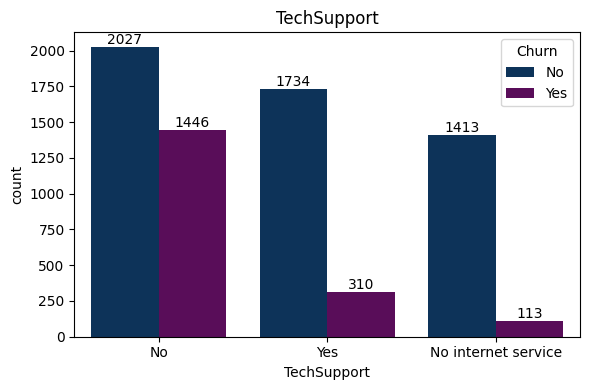

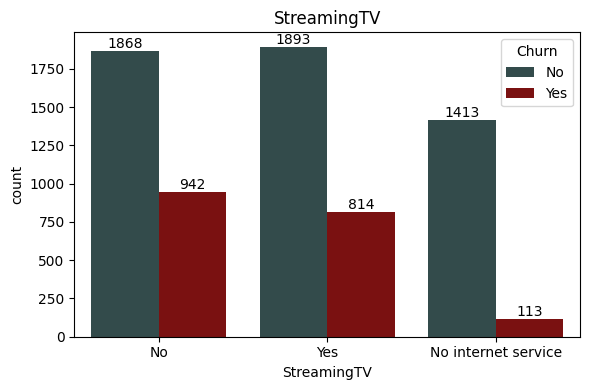

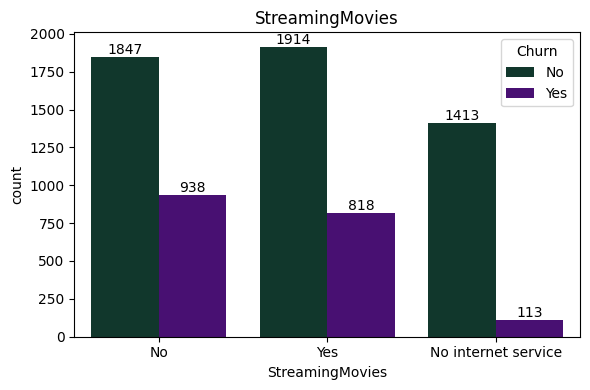

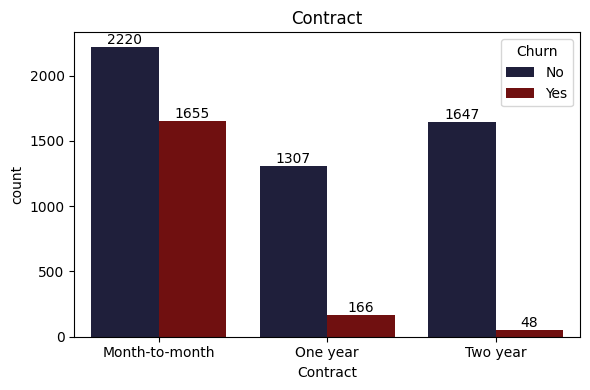

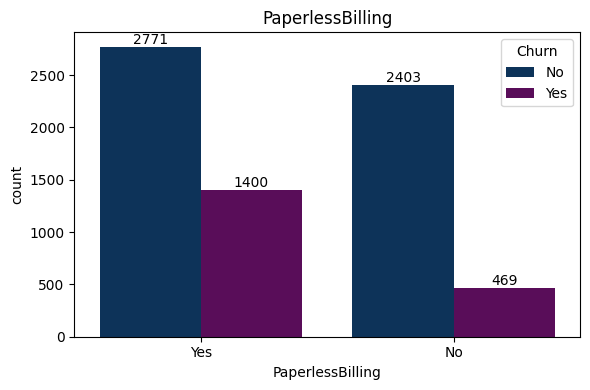

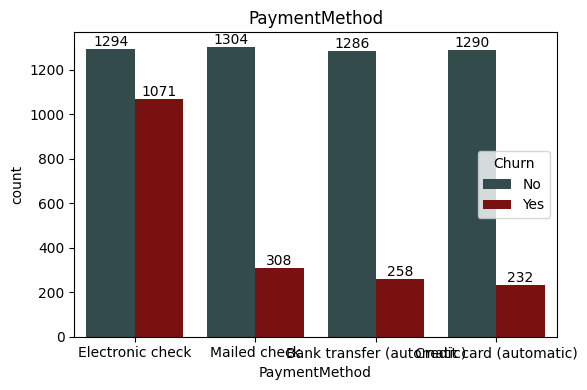

In [15]:
dark_palettes = [
    ['#0b3d2e', '#4b0082'],  # dark green, indigo
    ['#1a1a40', '#800000'],  # navy, maroon
    ['#003366', '#660066'],  # deep blue, purple
    ['#2f4f4f', '#8b0000'],  # dark slate, dark red
]

for i, predictor in enumerate(df.drop(columns=['customerID','Churn', 'TotalCharges', 'MonthlyCharges', 'tenure'])):
    plt.figure(i, figsize=(6, 4))
    
    palette = dark_palettes[i % len(dark_palettes)]
    
    ax = sns.countplot(data=df, x=predictor, hue='Churn', palette=palette)
    plt.title(predictor)
    
    for container in ax.containers:
        ax.bar_label(container)
        
    plt.tight_layout()
    plt.show()

 <a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Data Preprocessing</div>

In [16]:
ros = RandomOverSampler()

In [17]:
X,y=ros.fit_resample(X,y)

In [18]:
y.value_counts()

Churn
No       5174
Yes      5174
Name: count, dtype: int64

In [19]:
categorical_features = ['gender', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']
numeric_features = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

<a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">Model Building and Evaluation </div>

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

<a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">DecisionTree Pipeline</div>

In [22]:
#clf=DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=25,min_samples_split=5,min_samples_leaf=1,max_features=20,max_leaf_nodes=None,min_impurity_decrease=0.0)
#clf=DecisionTreeClassifier()

In [23]:
pipeline = Pipeline(steps=[("preprocessor",preprocessor),("Classifier",DecisionTreeClassifier())])

In [24]:
pipeline.fit(X_train,y_train.values.ravel())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OrdinalEncoder(),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('Classifier', DecisionTreeClassifier())])

In [25]:
y_pred=pipeline.predict(X_test)

## DecisionTree Accuracy For test

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.95      0.81      0.87      1298
         Yes       0.83      0.96      0.89      1289

    accuracy                           0.88      2587
   macro avg       0.89      0.88      0.88      2587
weighted avg       0.89      0.88      0.88      2587



## DecisionTree Accuracy For train

In [27]:
y_pred=pipeline.predict(X_train)

In [28]:
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00      3876
         Yes       1.00      1.00      1.00      3885

    accuracy                           1.00      7761
   macro avg       1.00      1.00      1.00      7761
weighted avg       1.00      1.00      1.00      7761



<a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">GridSearchCV Pipeline</div>

In [29]:
param_grid = {
    'Classifier__criterion': ['gini', 'entropy'],
    'Classifier__min_samples_split': [2, 5, 10],
    'Classifier__min_samples_leaf': [1, 2, 4],
    #'Classifier__max_features': ['sqrt', 'log2', None],
    'Classifier__max_depth': [None, 5, 10, 20]
}

In [30]:
grid=GridSearchCV(pipeline,param_grid,cv=5,n_jobs=-1)

In [31]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OrdinalEncoder(),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod']),
                                                                        ('num',
                                                                         'passthrough',
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges'])])),
                                       ('Classifier',
                                        DecisionTreeClassifier())]),
             n_jobs=-1,
             param_grid={'Classifier__criterion': ['gini', 'entropy'],
                         'Classifier__max_depth': [None, 5, 10, 20],
                         'Classifier__min_samples_leaf': [1, 2, 4],
                         'Classifier__min_samples_split': [2, 5, 10]})

In [32]:
grid.best_score_

np.float64(0.830820792480135)

In [33]:
grid.best_params_

{'Classifier__criterion': 'gini',
 'Classifier__max_depth': None,
 'Classifier__min_samples_leaf': 1,
 'Classifier__min_samples_split': 2}

In [34]:
y_pred=grid.predict(X_test)

## GridSearchCV Accuracy For test 

In [35]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.95      0.80      0.87      1298
         Yes       0.83      0.96      0.89      1289

    accuracy                           0.88      2587
   macro avg       0.89      0.88      0.88      2587
weighted avg       0.89      0.88      0.88      2587



## GridSearchCV Accuracy For train

In [36]:
y_pred=grid.predict(X_train)

In [37]:
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00      3876
         Yes       1.00      1.00      1.00      3885

    accuracy                           1.00      7761
   macro avg       1.00      1.00      1.00      7761
weighted avg       1.00      1.00      1.00      7761



<a id="1"></a>
# <div style="text-align:center; border-radius:20px; padding:14px; font-family:Trebuchet MS, sans-serif; background:linear-gradient(90deg,#141e30,#243b55,#2c5364); box-shadow:0px 4px 12px rgba(0,0,0,0.4); color:white; font-size:130%; font-weight:bold; overflow:hidden;">RandomForest Pipeline</div>

In [38]:
pipeline = Pipeline(steps=[("preprocessor",preprocessor),("Classifier",RandomForestClassifier())])

In [39]:
pipeline.fit(X_train,y_train.values.ravel())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OrdinalEncoder(),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('Classifier', RandomForestClassifier())])

In [40]:
y_pred = pipeline.predict(X_test)

## RandomForest Accuracy For test 

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          No       0.96      0.84      0.89      1298
         Yes       0.86      0.96      0.91      1289

    accuracy                           0.90      2587
   macro avg       0.91      0.90      0.90      2587
weighted avg       0.91      0.90      0.90      2587



## RandomForest Accuracy For train 

In [42]:
y_pred=pipeline.predict(X_train)

In [43]:
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00      3876
         Yes       1.00      1.00      1.00      3885

    accuracy                           1.00      7761
   macro avg       1.00      1.00      1.00      7761
weighted avg       1.00      1.00      1.00      7761



In [44]:
# import pickle
# pickle.dump(pipeline, open("model.pkl","wb"))